# PREPROCESSING


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder

This code brings in useful tools to help work with data. It uses pandas and numpy to handle and change data easily. For making charts and graphs, it uses matplotlib and seaborn. The missingno tool helps show where data might be missing. It also includes tools from sklearn to prepare data before using it in a machine learning model. These tools include LabelEncoder and OneHotEncoder to change words into numbers, and MinMaxScaler and StandardScaler to make sure numbers are on the same scale.

In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv", delimiter=",")
print(df.head())

df.shape
df.columns

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

This code reads a CSV file named "diabetes_prediction_dataset.csv" and shows the first few rows to give a quick look at the data. The df = pd.read_csv(...) line loads the file into a DataFrame called df. The print(df.head()) line prints the first 5 rows. The df.shape shows the number of rows and columns in the data, and df.columns lists all the column names.

In [ ]:
df.head()
df.info()
df.dtypes
df.head()
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   a

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


This part of the code is used to take a closer look at the dataset. The df.head() command shows the first few rows so you can quickly see what the data looks like. The df.info() line gives a summary, including how many rows there are, the column names, and if any data is missing. The df.dtypes shows the type of data in each column, like numbers or text. These steps are useful for understanding the structure of the dataset before working with it.

In [ ]:
# Renaming columns

df.columns = ['gender', 'age', 'hypertension',
                'heart_disease', 'smoking_history','bmi_score',
                'haemoglobin_level', 'blood_glucose_level', 'is_diabetic']

This part of the code renames the columns in the dataset to make them easier to read and understand, especially during data cleaning and analysis. The new names like 'gender', 'age', 'bmi_score', and 'is_diabetic' are simpler and more descriptive. This helps avoid confusion and makes the code clearer when working with the data later on.

## HANDLING MISSING VALUES

In [ ]:
for column in df:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Missing values in {column}:", df[column].isnull().sum())
    print()

missing_values = df.isnull().sum()
print(missing_values.to_dict())

df.dropna(axis=1, how='all', inplace=True)

print("Remaining columns:")
print(df.columns)

df.dropna(inplace=True)

print("Shape of DataFrame after removing rows with missing values:", df.shape)

Unique values in age: 81
Missing values in age: 0

Unique values in hypertension: 2
Missing values in hypertension: 0

Unique values in heart_disease: 2
Missing values in heart_disease: 0

Unique values in bmi_score: 4247
Missing values in bmi_score: 0

Unique values in haemoglobin_level: 18
Missing values in haemoglobin_level: 0

Unique values in blood_glucose_level: 18
Missing values in blood_glucose_level: 0

Unique values in is_diabetic: 2
Missing values in is_diabetic: 0

Unique values in gender_Female: 2
Missing values in gender_Female: 0

Unique values in gender_Male: 2
Missing values in gender_Male: 0

Unique values in gender_Other: 2
Missing values in gender_Other: 0

Unique values in smoking_history_current: 2
Missing values in smoking_history_current: 0

Unique values in smoking_history_former: 2
Missing values in smoking_history_former: 0

Unique values in smoking_history_never: 2
Missing values in smoking_history_never: 0

Unique values in smoking_history_no info: 2
Missin

This part of the code checks each column to see how many unique values it has and how many missing values are present. It then shows the total number of missing values in all columns. After that, it removes any columns that have only missing values using df.dropna(axis=1, how='all'). Then, it removes any rows that contain missing values using df.dropna(). Finally, it prints the remaining column names and shows the new shape of the DataFrame. This helps clean the dataset so it’s ready for analysis or machine learning without errors caused by missing data.









## HANDLING DUPLICATES

In [ ]:
for column in df.columns:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Number of duplicates in '{column}' column: {df[column].duplicated().sum()} \n")

unique_columns = []
for column in df.columns:
    if df[column].nunique() == len(df):
        unique_columns.append(column)

print("Columns where each row is unique:")
print(unique_columns)

for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print()

Unique values in gender: 3
Number of duplicates in 'gender' column: 99997 

Unique values in age: 102
Number of duplicates in 'age' column: 99898 

Unique values in hypertension: 2
Number of duplicates in 'hypertension' column: 99998 

Unique values in heart_disease: 2
Number of duplicates in 'heart_disease' column: 99998 

Unique values in smoking_history: 6
Number of duplicates in 'smoking_history' column: 99994 

Unique values in bmi_score: 4247
Number of duplicates in 'bmi_score' column: 95753 

Unique values in haemoglobin_level: 18
Number of duplicates in 'haemoglobin_level' column: 99982 

Unique values in blood_glucose_level: 18
Number of duplicates in 'blood_glucose_level' column: 99982 

Unique values in is_diabetic: 2
Number of duplicates in 'is_diabetic' column: 99998 

Columns where each row is unique:
[]
Unique values in column 'gender':
['Female' 'Male' 'Other']

Unique values in column 'age':
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   

This part of the code helps identify unique values and duplicates in each column of the dataset. It loops through all columns to print the number of unique values and the number of duplicate entries for each column. The second part checks which columns have only unique values in each row (i.e., columns where the number of unique values is equal to the total number of rows) and stores those columns in a list called unique_columns. Finally, it prints out the unique values in each column, allowing you to see the distinct entries. This helps to identify any columns that might not provide useful information, such as an ID column with unique identifiers.

In [ ]:
print("Number of duplicate rows in the dataset: ", df.duplicated().sum())

df = df.drop_duplicates()

print(f"Number of Duplcate rows after deleting duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows in the dataset:  190
Number of Duplcate rows after deleting duplicate rows: 0


This code checks for duplicate rows in the dataset. The line df.duplicated().sum() counts the number of duplicate rows (rows that are identical to others). It then removes any duplicate rows using df.drop_duplicates() and prints the number of duplicates again to show how many are left. This helps ensure that the dataset doesn’t have repeated entries, which could affect analysis or modeling.

## HANDLING OUTLIERS

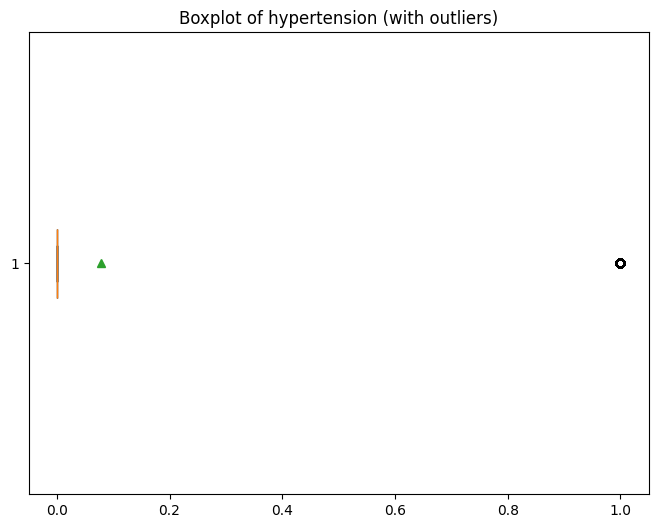

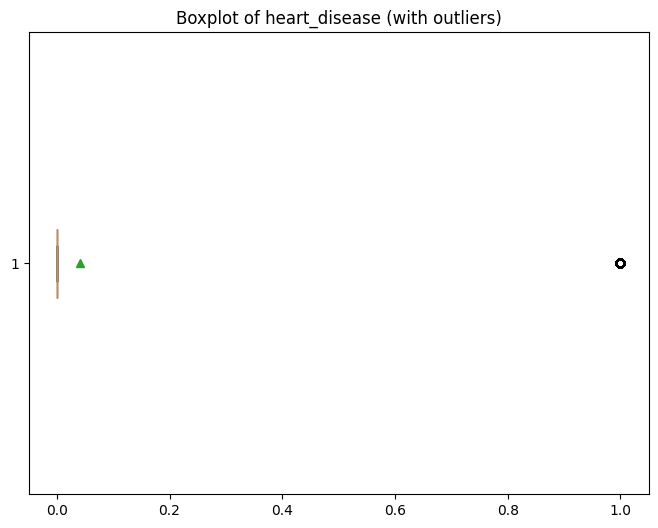

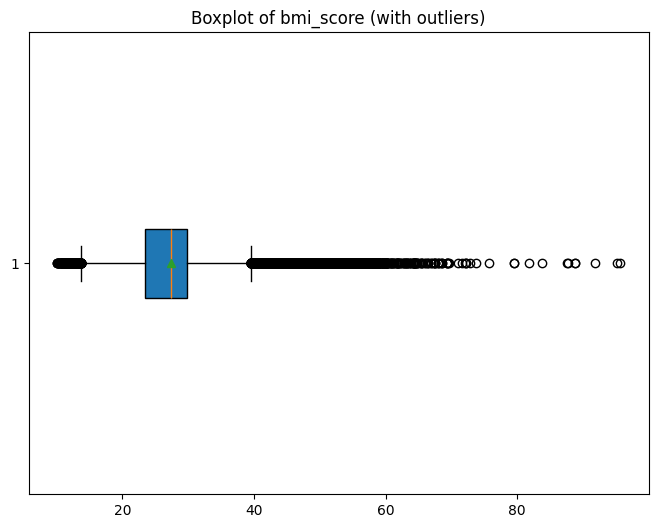

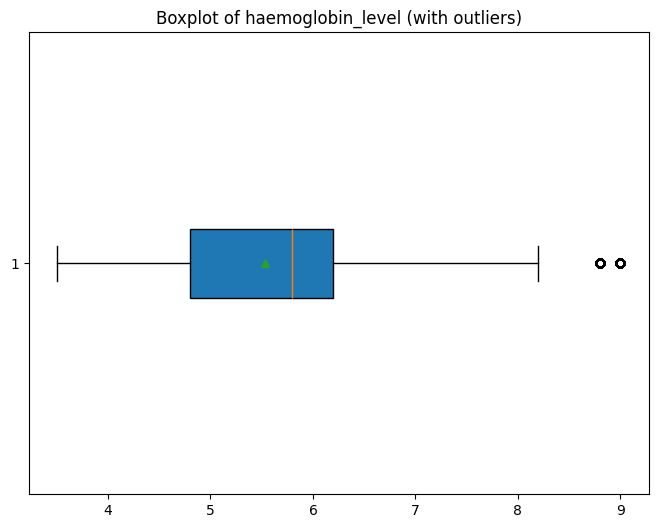

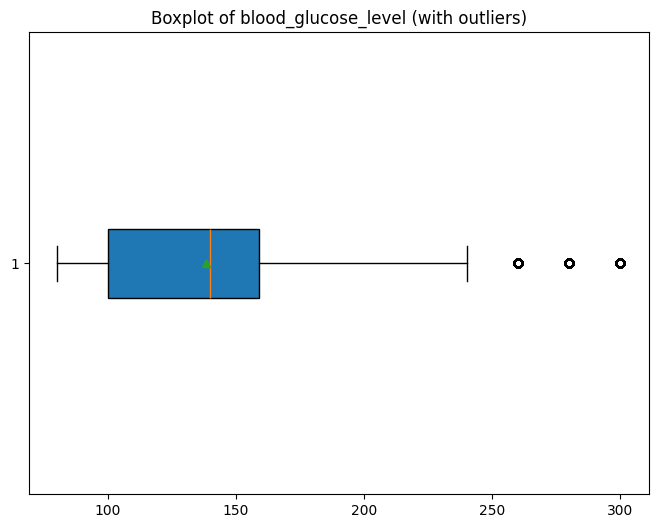

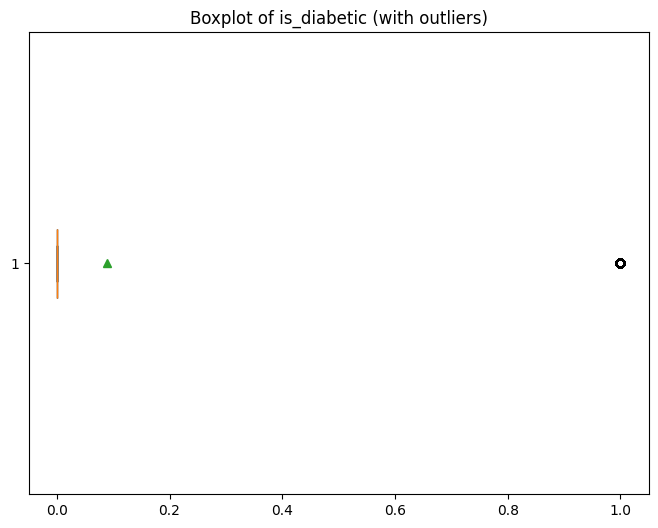

In [ ]:
def detect_outliers_iqr(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        if not column_outliers.empty:
            outliers[column] = column_outliers
    return outliers

outliers_iqr = detect_outliers_iqr(df)

for column, values in outliers_iqr.items():
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (with outliers)')
    plt.show()

This code defines a function detect_outliers_iqr() that identifies outliers in the dataset using the Interquartile Range (IQR) method. It calculates the first and third quartiles (Q1 and Q3) and the IQR for each numerical column, then identifies values outside the bounds of Q1 - 1.5 * IQR and Q3 + 1.5 * IQR as outliers. The function stores the outliers in a dictionary, which is then used to create boxplots for each column with outliers. The boxplots visualize the distribution of the data and highlight the outliers, helping to identify and assess extreme values in the dataset.

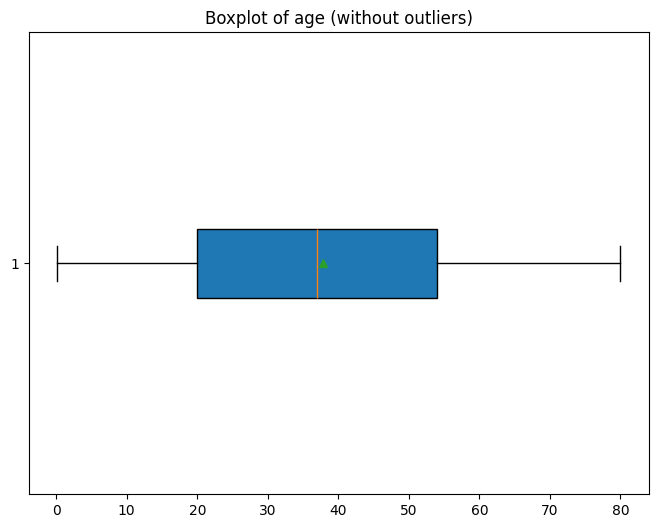

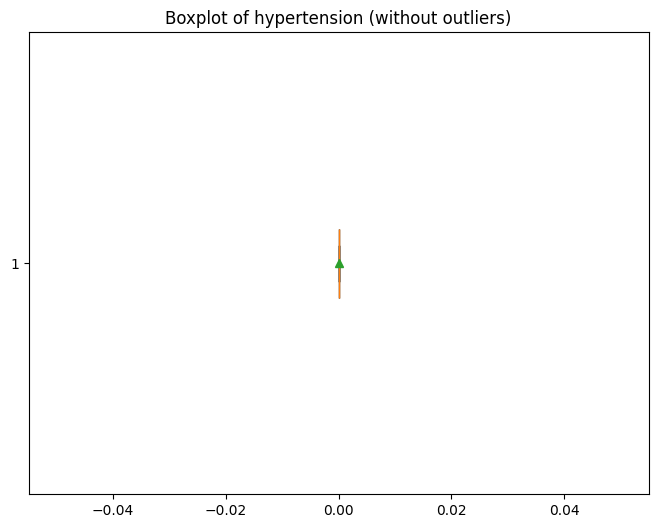

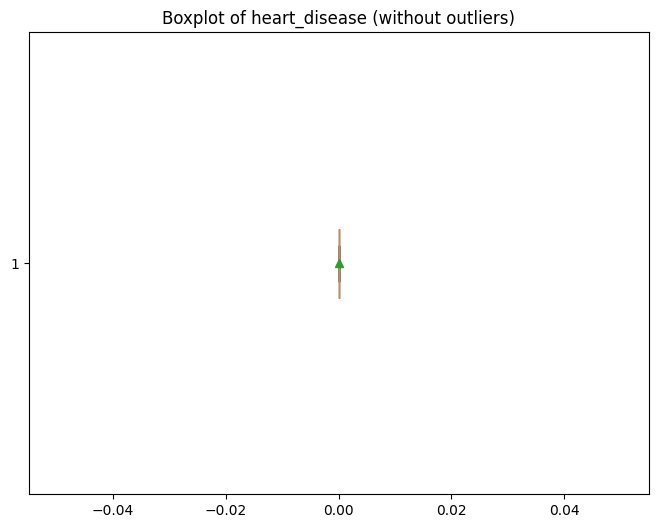

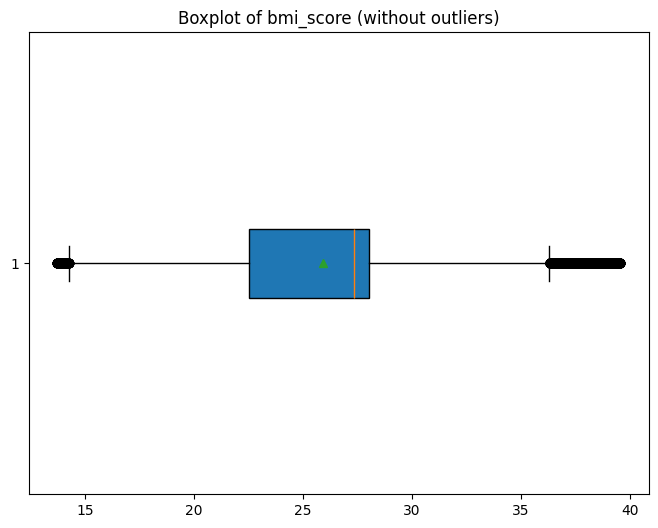

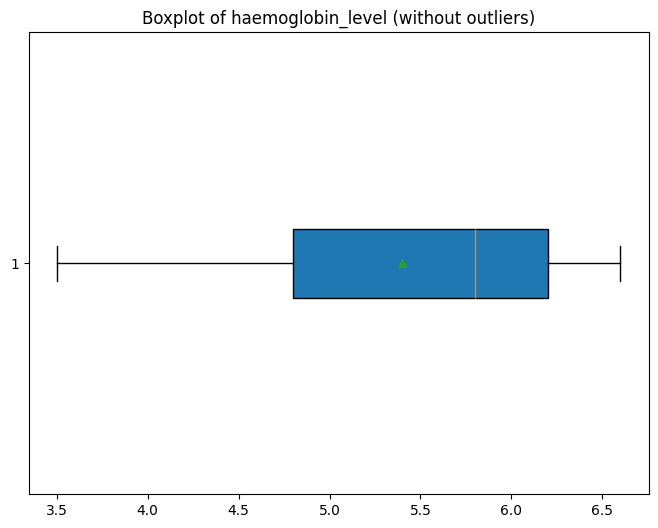

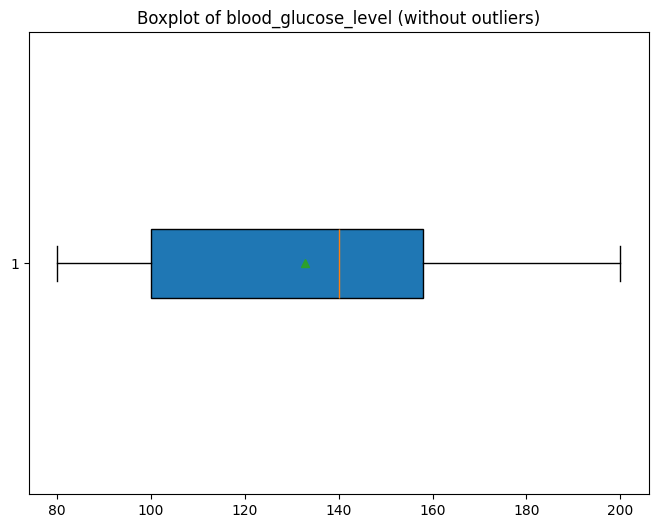

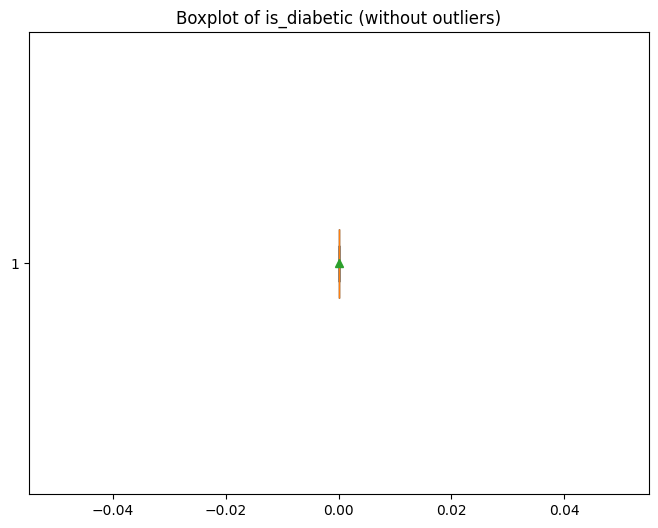

In [ ]:
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df

df_cleaned = remove_outliers_iqr(df)

for column in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (without outliers)')
    plt.show()

This code defines a function remove_outliers_iqr() that removes outliers from the dataset using the Interquartile Range (IQR) method. It calculates the first and third quartiles (Q1 and Q3), determines the IQR, and identifies the lower and upper bounds for normal values in each numerical column. Rows with values outside these bounds are excluded from the dataset. The cleaned DataFrame is returned without the outliers. After cleaning, the code generates boxplots for each numerical column in the cleaned dataset, visually showing the data distribution without the outliers. This helps to ensure the dataset is free from extreme values that might distort analysis or modeling.

## CHECKING THE COUNT AND VALUE OF RECORDS PER CATEGORY

In [ ]:

df.value_counts()


gender  age    hypertension  heart_disease  smoking_history  bmi_score  haemoglobin_level  blood_glucose_level  is_diabetic
Other   55.00  0             0              No Info          27.32      5.0                158                  0              1
Female  0.08   0             0              No Info          11.88      5.7                80                   0              1
Other   10.00  0             0              not current      14.09      5.0                140                  0              1
        7.00   0             0              No Info          27.32      3.5                159                  0              1
Male    80.00  1             1              not current      34.56      6.2                145                  0              1
                                                                                                                              ..
Female  0.08   0             0              No Info          13.03      6.2                158                  0              1
                                                             12.82      3.5                90                   0              1
                                                             12.77      4.5                160                  0              1
                                                             12.74      3.5                140                  0              1
                                                             12.50      4.5                155                  0              1
Name: count, Length: 96146, dtype: int64

The df.value_counts() function counts the number of occurrences of each unique value in the dataset. It is usually applied to a specific column, but if you call it on the entire DataFrame (df.value_counts()), it will give the counts of unique rows across all columns combined. It is helpful for understanding the distribution of values and identifying any imbalances or patterns in categorical data. However, if used on a large DataFrame with many columns, it might produce a lengthy output.

In [ ]:
print(df.age.max())
print(df.age.min())

80.0
0.08


This code is used to find the highest and lowest values in the age column of the dataset. The df.age.max() function returns the maximum age, while df.age.min() returns the minimum age. These values help in understanding the range of ages in the dataset and can also be useful for identifying any outliers or unrealistic values in the data, ensuring that the data is within a reasonable range.

In [ ]:
df.age = df.age.astype(int)
df.age.dtype

df.age.value_counts()

print(df.age.max())
print(df.age.min())

80
0


This code first changes the data type of the age column to integers using df.age.astype(int). The df.age.dtype line checks and confirms the data type of the age column after the conversion. Then, df.age.value_counts() is used to count how many times each unique age appears in the column. Finally, it prints the maximum and minimum values in the age column to understand the range of ages. Converting the age column to integers ensures that the values are stored as whole numbers, which is often expected for age-related data.

In [ ]:
print("BMI_SCORE:", df.bmi_score.min(), "to", df.bmi_score.max())
print("HEMOGLOBIN_LEVEL:", df.haemoglobin_level.min(), "to", df.haemoglobin_level.max())
print("BLOOD_GLUCOSE_LEVEL:", df.blood_glucose_level.min(), "to", df.blood_glucose_level.max())


BMI_SCORE: 10.01 to 95.69
HEMOGLOBIN_LEVEL: 3.5 to 9.0
BLOOD_GLUCOSE_LEVEL: 80 to 300


This code prints the range of values for three health-related columns in the dataset. It shows the minimum and maximum values for bmi_score, haemoglobin_level, and blood_glucose_level. This helps to understand the spread or range of each of these features, which can be useful for detecting any unusual values or preparing the data for further analysis, such as normalization or feature scaling.

## PREPROCESSING THE SMOKING HISTORY WITH UNNECCESARY CATEGORY

In [ ]:

df.smoking_history.value_counts()

,count
smoking_history,
never,34398
No Info,32887
former,9299
current,9197
not current,6367
ever,3998


This line of code counts how many times each unique value appears in the smoking_history column, helping to understand how smoking habits are distributed in the dataset. It shows categories like "never", "former", "current", and others. However, some entries such as "former","ever" and "not current" may be unnecessary or unclear, as they could mean the same thing or create confusion. These values might need to be cleaned or combined to make the data more consistent and easier to analyze.

In [ ]:
# cleaning Smoking_history column

def clean_smoking_history(value):

    if value == "No Info":
        return "no info"
    elif value == "ever":
        return "current"
    elif value == "not current":
        return "former"
    else:
        return value

df.smoking_history = df.smoking_history.apply(clean_smoking_history)

This code defines a function called clean_smoking_history() to clean and standardize the values in the smoking_history column. It changes "No Info" to "no info", "ever" to "current", and "not current" to "former" for consistency. Any other values are kept as they are. The function is then applied to the entire smoking_history column using .apply(). This helps make the data cleaner and easier to work with by ensuring that similar meanings are grouped under the same label.

In [ ]:
df.smoking_history.value_counts()

,count
smoking_history,
never,34398
no info,32887
former,15666
current,13195


This line of code shows how many times each unique value appears in the smoking_history column after it has been cleaned. It helps confirm that the changes, such as turning "ever" into "current" and "not current" into "former", were done correctly. It also gives a clearer view of how smoking habits are grouped in the dataset.

## CHECKING IF SMOKING HISTORY MATCHES THE AGE

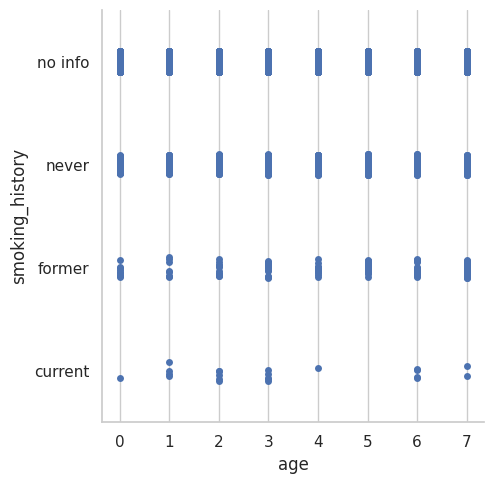

In [ ]:


sns.set(style="whitegrid")

sns.catplot(x="age", y="smoking_history", data=df.loc[df['age'] <=7])

plt.show()

This code creates a visual plot to show the relationship between age and smoking_history for rows where the age is 7 or younger. It uses Seaborn's catplot, which is good for showing the distribution of categories. The sns.set(style="whitegrid") line sets a clean background for better readability. This plot can help check for unusual or incorrect data, since very young children usually should not have a smoking history.










In [ ]:
df = df[~((df['age'] < 7) & df['smoking_history'].isin(['ever', 'current']))]

This line of code removes rows where the age is less than 7 and the smoking_history is either "ever" or "current". The ~ symbol means "not", so it keeps only the rows that do not match this condition. This helps clean the data by removing unrealistic cases, since very young children should not have a smoking history marked as "ever" or "current".

In [ ]:
df.shape

(96126, 9)

This line of code returns the shape of the DataFrame, showing the number of rows and columns after the filtering operation. It helps you check how many entries remain in the dataset after removing the unrealistic cases where the age was less than 7 and the smoking history was "ever" or "current".

## TRANSFORMING SOME COLUMN WITH NUMERICAL DATA TO CATEGORICAL

In [ ]:
df = pd.get_dummies(data=df)

df.head()

,age,hypertension,heart_disease,bmi_score,haemoglobin_level,blood_glucose_level,is_diabetic,gender_Female,gender_Male,gender_Other,smoking_history_current,smoking_history_former,smoking_history_never,smoking_history_no info
0,80,0,1,25.19,6.6,140,0,True,False,False,False,False,True,False
1,54,0,0,27.32,6.6,80,0,True,False,False,False,False,False,True
2,28,0,0,27.32,5.7,158,0,False,True,False,False,False,True,False
3,36,0,0,23.45,5.0,155,0,True,False,False,True,False,False,False
4,76,1,1,20.14,4.8,155,0,False,True,False,True,False,False,False


This code converts categorical variables in the df DataFrame into dummy/indicator variables using pd.get_dummies(). It creates a new column for each unique category in the original categorical columns, where each column contains 1 or 0 to indicate the presence of a particular category. The df.head() line then displays the first few rows of the modified DataFrame, showing the new dummy variables and how the data has been transformed. This is commonly done before applying machine learning models that require numerical input.

## Feature Scaling Using Min-Max Normalization

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

columns_to_scale = ['age', 'bmi_score','haemoglobin_level','blood_glucose_level']

scaler.fit(df[columns_to_scale])

scaled_columns = scaler.transform(df[columns_to_scale])

df[columns_to_scale] = scaled_columns

This code uses the MinMaxScaler from sklearn.preprocessing to scale numerical columns in the DataFrame, transforming the values to a range between 0 and 1. The columns selected for scaling are age, bmi_score, haemoglobin_level, and blood_glucose_level. First, the scaler is fitted to these columns using scaler.fit(). Then, the transformation is applied with scaler.transform(), and the scaled values are stored back into the original columns. This scaling is commonly done to ensure that numerical features are on the same scale, which can improve the performance of machine learning models.

In [ ]:
df.shape

(96126, 14)

## Compute correlation matrix

<ipython-input-90-119a9d61c29b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, palette='coolwarm')


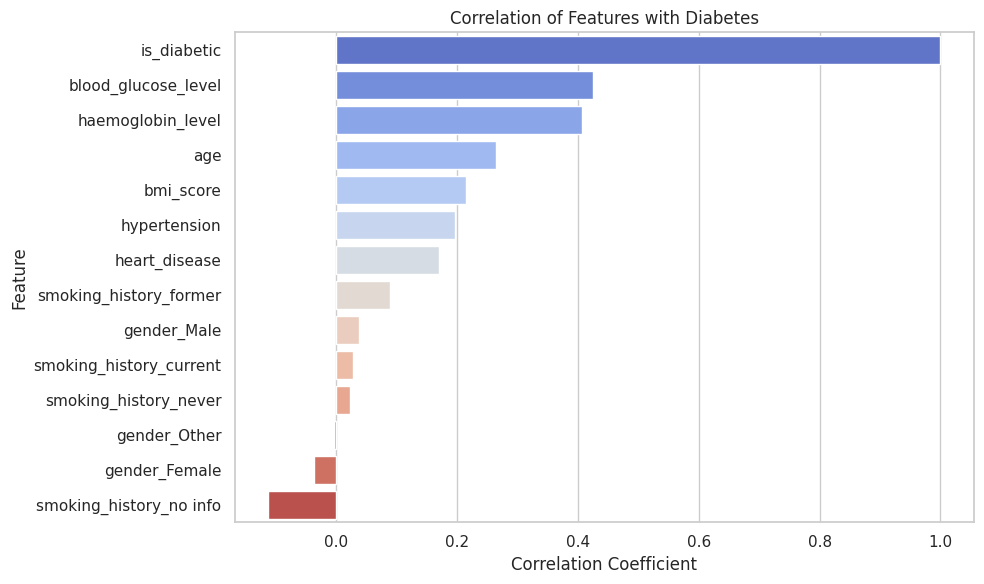

In [ ]:

correlation_matrix = df.corr()

# Get correlation with target variable 'diabetes'
correlation_with_target = correlation_matrix['is_diabetic'].sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, palette='coolwarm')
plt.title('Correlation of Features with Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This code calculates the correlation matrix of the dataset using df.corr(), which computes the correlation between all numerical features. It then extracts the correlation values with the target variable is_diabetic and sorts them in descending order. A bar plot is created using Seaborn to visualize the correlation coefficients of each feature with the is_diabetic column. The plot shows how strongly each feature is related to the target variable, helping to identify the most important features for predicting diabetes. The coolwarm color palette is used to indicate the strength and direction of the correlations.

In [ ]:
# Drop multiple columns
df = df.drop(['gender_Other', 'smoking_history_no info'], axis=1)

This code removes two specific columns, gender_Other and smoking_history_no info, from the DataFrame using the df.drop() method. The axis=1 argument specifies that columns (not rows) should be dropped. This step is typically done to eliminate unnecessary or irrelevant columns from the dataset, ensuring a cleaner and more focused set of features for analysis or modeling.

In [ ]:
df.shape

(96126, 12)

## BALANCING THE DATASET

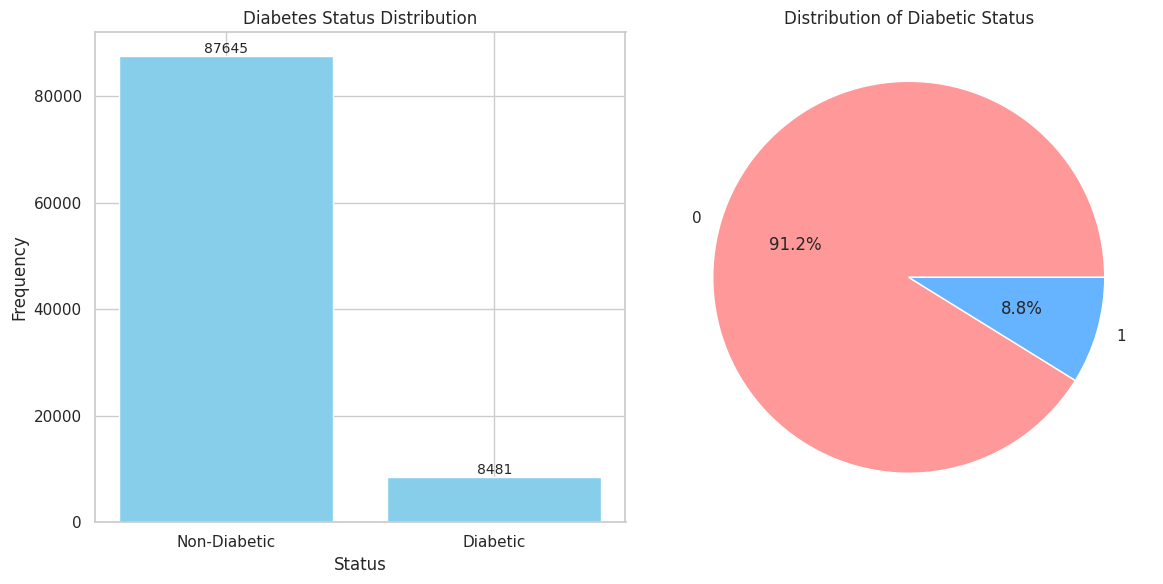

In [ ]:
# Count the occurrences of each diabetic status
status_counts = df['is_diabetic'].value_counts()

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for the diabetic status
axes[0].bar(status_counts.index, status_counts.values, color='skyblue')

axes[0].set_title('Diabetes Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# Add count annotations to the bars
for idx, count in enumerate(status_counts.values):
    axes[0].text(idx, count, str(count), ha='center', va='bottom', fontsize=10)

# Pie chart for the diabetic status distribution
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Distribution of Diabetic Status')

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plots
plt.show()


This dataset, after some cleaning, still has 87,645 non-diabetic (0) instances and 8,481 diabetic (1) instances, resulting in a noticeable imbalance between the two classes. Such an imbalance can pose a challenge for machine learning models, as they may become biased towards predicting the majority class (non-diabetic) more often, leading to poor performance in predicting the minority class (diabetic). This imbalance can significantly affect the model's ability to correctly identify diabetic cases, which are often more critical to predict accurately. To address this issue, techniques such as oversampling the diabetic (minority) class, undersampling the non-diabetic (majority) class, or adjusting class weights within the model can be applied. These methods help ensure that the model learns to recognize patterns in both classes effectively, improving its overall predictive accuracy.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pandas as pd

# Split the dataset into features (X) and target (y)
X_features = df.drop(columns='is_diabetic')
y_target = df['is_diabetic']

# Step 1: Apply SMOTE to create a balanced dataset by oversampling the minority class
smote_technique = SMOTE(random_state=42)
X_resampled, y_resampled = smote_technique.fit_resample(X_features, y_target)

# Step 2: Combine the resampled features and target into a DataFrame for easier handling
df_resampled = pd.DataFrame(X_resampled)
df_resampled['is_diabetic'] = y_resampled

# Step 3: Downsample the resampled dataset to a fixed number of 10,000 rows
df_downsampled = resample(df_resampled, replace=False, n_samples=10000, random_state=42)

# Check the distribution of the classes in the final balanced dataset
print("Balanced Class Distribution:")
print(df_downsampled['is_diabetic'].value_counts())


Balanced Class Distribution:
is_diabetic
1    5039
0    4961
Name: count, dtype: int64


This code addresses the class imbalance in the dataset by applying the SMOTE technique to oversample the minority class (diabetic individuals), creating synthetic samples to balance the dataset. After SMOTE is applied, the dataset is downsampled to 10,000 rows to ensure a manageable size while maintaining balance. The final dataset is then checked for class distribution to verify that the diabetic and non-diabetic classes are now more evenly represented. This process helps mitigate the risk of bias in machine learning models that could otherwise favor the majority class due to the original imbalance.

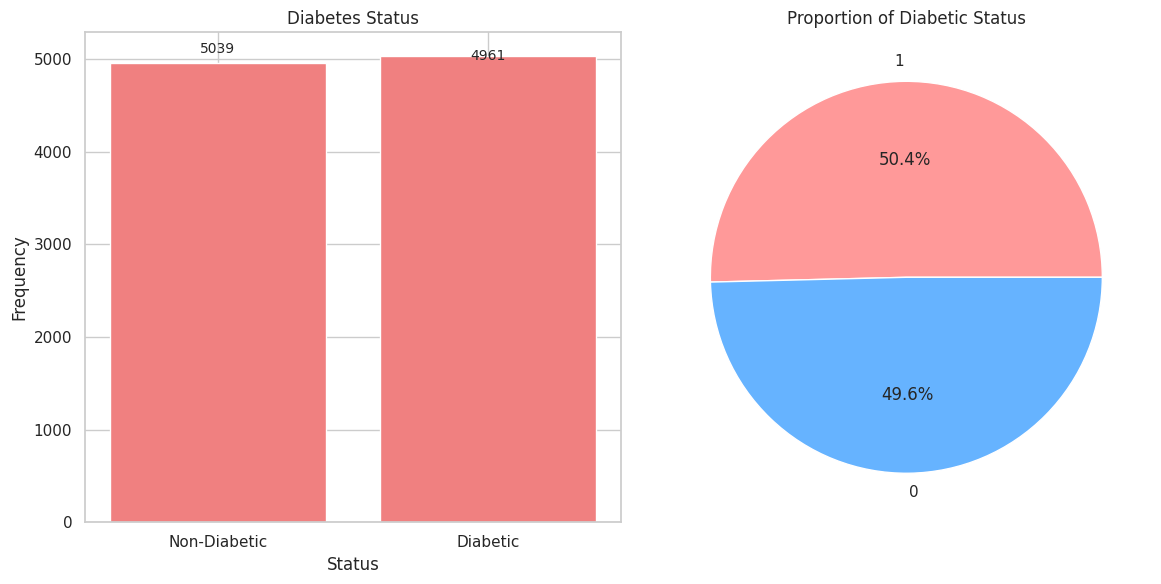

In [ ]:
# Count the distribution of diabetic status in the balanced dataset
status_distribution = df_balanced['is_diabetic'].value_counts()

# Create subplots for the bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for diabetic status distribution
axes[0].bar(status_distribution.index, status_distribution.values, color='lightcoral')

axes[0].set_title('Diabetes Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# Annotate the bars with their respective counts
for idx, count in enumerate(status_distribution.values):
    axes[0].text(idx, count, str(count), ha='center', va='bottom', fontsize=10)

# Pie chart for the diabetic status distribution
axes[1].pie(status_distribution, labels=status_distribution.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Proportion of Diabetic Status')

# Adjust layout for better spacing between plots
plt.tight_layout()

# Display the plots
plt.show()


This code visualizes the distribution of diabetic and non-diabetic individuals in the dataset after applying SMOTE and downsampling to balance the classes. It uses a bar chart to show the count of each class, with annotations for clarity, and a pie chart to display the proportion of diabetic versus non-diabetic individuals. These visualizations confirm that the dataset is now balanced, addressing the class imbalance issue. By ensuring equal representation of both classes, the balanced dataset provides a more reliable foundation for training machine learning models, minimizing bias towards the majority class.

In [ ]:
df_balanced

,age,hypertension,heart_disease,bmi_score,haemoglobin_level,blood_glucose_level,gender_Female,gender_Male,smoking_history_current,smoking_history_former,smoking_history_never,is_diabetic
17024,0.687500,0,0,0.218137,0.418182,0.209091,True,False,True,False,False,0
95818,0.687500,0,0,0.202848,0.272727,0.227273,True,False,False,True,False,0
174186,0.106951,0,0,0.104652,0.504036,0.887213,True,False,False,False,False,1
144831,0.850000,0,0,0.218527,0.952752,0.818182,True,False,False,False,True,1
120226,0.532043,0,0,0.186521,0.963636,0.656208,False,True,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
46183,0.062500,0,0,0.047852,0.545455,0.354545,True,False,False,False,False,0
92291,0.500000,0,0,0.250817,0.000000,0.340909,True,False,False,False,True,0
73746,0.175000,0,0,0.163632,0.000000,0.363636,False,True,False,False,False,0
163311,0.697313,0,0,0.290451,0.600000,0.727273,True,False,False,False,True,1


The df_balanced DataFrame represents the dataset after applying SMOTE to oversample the minority class (diabetic individuals) and then downsampling the resulting balanced data to a total of 10,000 rows. This ensures that both the diabetic and non-diabetic classes are equally represented, mitigating the issues caused by class imbalance. The dataset now contains a more balanced distribution of the target variable (is_diabetic), which is crucial for building fair and unbiased machine learning models.

In [ ]:
df_balanced.shape
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 17024 to 94546
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      10000 non-null  float64
 1   hypertension             10000 non-null  int64  
 2   heart_disease            10000 non-null  int64  
 3   bmi_score                10000 non-null  float64
 4   haemoglobin_level        10000 non-null  float64
 5   blood_glucose_level      10000 non-null  float64
 6   gender_Female            10000 non-null  bool   
 7   gender_Male              10000 non-null  bool   
 8   smoking_history_current  10000 non-null  bool   
 9   smoking_history_former   10000 non-null  bool   
 10  smoking_history_never    10000 non-null  bool   
 11  is_diabetic              10000 non-null  int64  
dtypes: bool(5), float64(4), int64(3)
memory usage: 673.8 KB


The df_balanced.shape and df_balanced.info() functions provide an overview of the structure and characteristics of the balanced dataset. The .shape function returns the dimensions of the DataFrame, showing the number of rows and columns after applying SMOTE and downsampling. Meanwhile, .info() gives detailed information about the dataset, including the number of non-null entries in each column, the data types of the columns, and whether there are any remaining missing values. These steps ensure that the dataset is properly structured and ready for further analysis or model training.

In [ ]:
# Exporting cleaned data into .csv file

df_balanced.to_csv("diabetes_clean.csv", index = False)

This line of code exports the df_balanced DataFrame into a CSV file named "diabetes_clean.csv". The index=False argument ensures that the index column is not included in the exported file. This is useful for saving the cleaned and balanced dataset for future use, such as training machine learning models or sharing the dataset with others. The resulting CSV file will contain the processed data, with balanced diabetic and non-diabetic instances.

# TRADITIONAL MODELS

This code implements a logistic regression model to predict diabetes status using a cleaned dataset, evaluated through 5-fold cross-validation. It begins by loading and standardizing the data, followed by training a logistic regression model configured with L2 regularization. For each fold, the model's performance is assessed on both training and testing sets, with accuracy metrics, confusion matrices, and overall classification reports collected to summarize results across all folds. Visualizations include a heatmap of the cumulative confusion matrix and a fold-wise accuracy plot to highlight consistency. Additionally, Principal Component Analysis (PCA) reduces the dataset to two dimensions for a visual representation of the logistic regression decision boundary, plotting both the sigmoid curve and data points to illustrate model behavior and classification probability.

=== Logistic Regression Evaluation ===

=== Overall Classification Report (Across All Folds) ===
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4961
           1       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Overall Training Accuracy:  0.8914
Overall Testing Accuracy:   0.8897


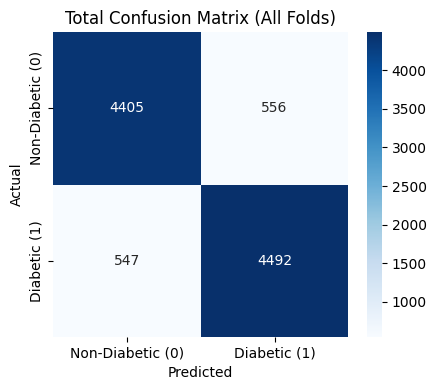

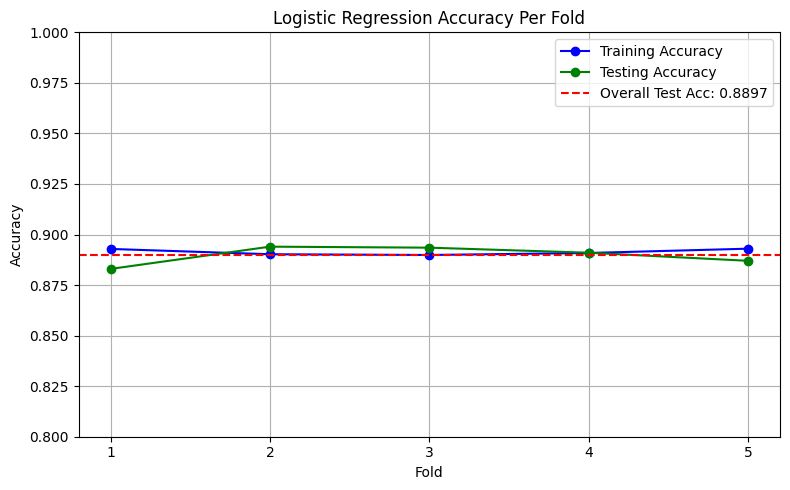


Fold Accuracies (Testing): ['0.8830', '0.8940', '0.8935', '0.8910', '0.8870']
Mean Testing Accuracy: 0.8897


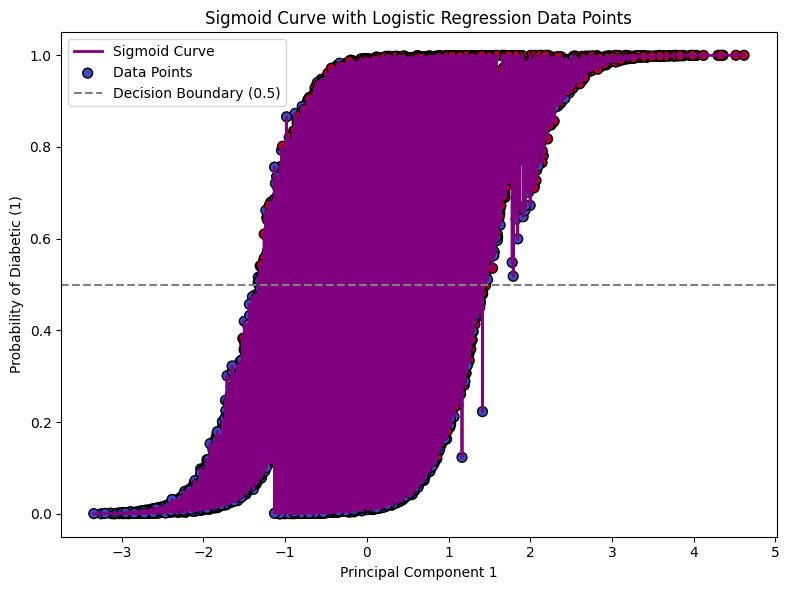

In [ ]:
#@title LOGISTIC REGRESSION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Model setup
model = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000)

# Tracking metrics
all_y_test = []
all_y_pred = []
train_acc = []
test_acc = []
conf_matrix_total = np.array([[0, 0], [0, 0]])  # Initialize confusion matrix

print("=== Logistic Regression Evaluation ===")

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Store true labels and predictions for the overall classification report
    all_y_test.extend(y_test)
    all_y_pred.extend(y_test_pred)

    # Accuracy for training and testing
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

    # Accumulate confusion matrix
    conf_matrix_total += confusion_matrix(y_test, y_test_pred)

# === Overall Classification Report ===
print("\n=== Overall Classification Report (Across All Folds) ===")
print(classification_report(all_y_test, all_y_pred))

# Calculate Overall Accuracy (Training and Testing)
overall_train_acc = np.mean(train_acc)
overall_test_acc = np.mean(test_acc)

print(f"\nOverall Training Accuracy:  {overall_train_acc:.4f}")
print(f"Overall Testing Accuracy:   {overall_test_acc:.4f}")

# Confusion Matrix (Total)
plt.figure(figsize=(4.5, 4))
sns.heatmap(conf_matrix_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('Total Confusion Matrix (All Folds)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# === Plot Training and Testing Accuracy Per Fold ===
plt.figure(figsize=(8, 5))
fold_range = range(1, len(train_acc) + 1)

plt.plot(fold_range, train_acc, marker='o', label='Training Accuracy', color='blue')
plt.plot(fold_range, test_acc, marker='o', label='Testing Accuracy', color='green')
plt.axhline(y=overall_test_acc, color='red', linestyle='--', label=f'Overall Test Acc: {overall_test_acc:.4f}')
plt.title("Logistic Regression Accuracy Per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(fold_range)
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === Fold Accuracies Summary ===
print("\nFold Accuracies (Testing):", [f"{acc:.4f}" for acc in test_acc])
print(f"Mean Testing Accuracy: {overall_test_acc:.4f}")


# === PCA for 2D visualization of decision boundary ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # Reduce features to 2D

# Fit Logistic Regression on the reduced dataset
model.fit(X_pca, y)

# Predict probabilities (this is the sigmoid curve)
probabilities = model.predict_proba(X_pca)[:, 1]  # Probabilities for class 1 (Diabetic)

# Sort the data by PC1 to plot the sigmoid curve smoothly
sorted_idx = np.argsort(X_pca[:, 0])
sorted_pc1 = X_pca[sorted_idx, 0]
sorted_probabilities = probabilities[sorted_idx]

# Plot the sigmoid curve
plt.figure(figsize=(8, 6))
plt.plot(sorted_pc1, sorted_probabilities, color='purple', label='Sigmoid Curve', linewidth=2)

# Plot the actual data points (with their class labels)
plt.scatter(X_pca[:, 0], probabilities, c=y, cmap='coolwarm', edgecolors='k', marker='o', s=50, label='Data Points')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.title('Sigmoid Curve with Logistic Regression Data Points')
plt.xlabel('Principal Component 1')
plt.ylabel('Probability of Diabetic (1)')
plt.legend()
plt.tight_layout()
plt.show()


The code applies a Decision Tree Classifier to predict diabetes status using a preprocessed dataset. It standardizes the features and employs 5-fold cross-validation to evaluate the model’s generalization ability. The tree is configured with a maximum depth of 10, using the Gini index for splitting. In each fold, the model is trained and tested, and performance metrics, including training and testing accuracy, are tracked. After cross-validation, an aggregated classification report and confusion matrix are presented to assess precision, recall, and overall performance. Fold-wise accuracy plots illustrate consistency across folds, and the tree structure is visualized in detail, showing how features contribute to decisions. This comprehensive evaluation aids in understanding both predictive strength and model interpretability.

=== Decision Tree Evaluation ===

=== Overall Classification Report (Across All Folds) ===
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      4961
           1       0.90      0.93      0.92      5039

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


Overall Training Accuracy:  0.9338
Overall Testing Accuracy:   0.9153


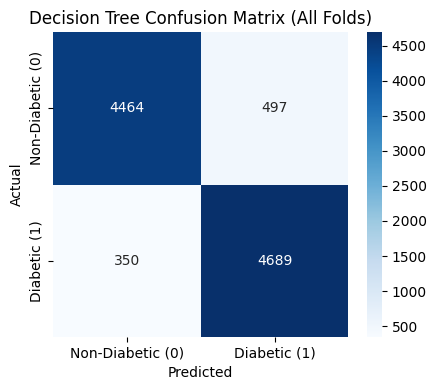

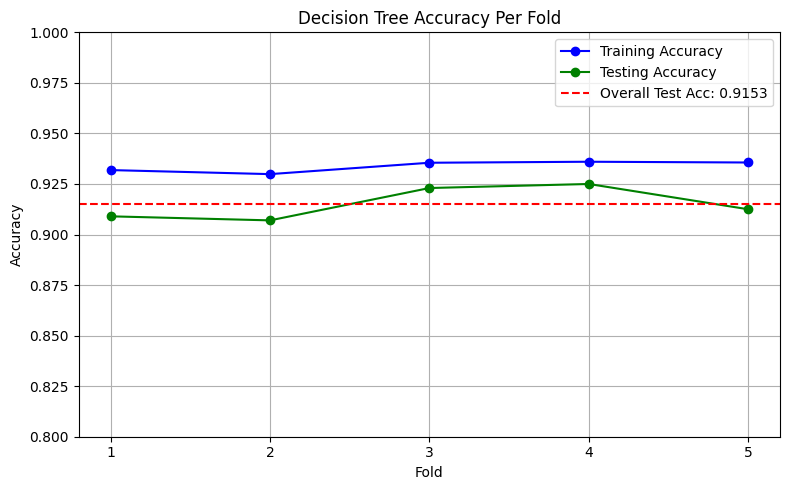


Fold Accuracies (Testing): ['0.9090', '0.9070', '0.9230', '0.9250', '0.9125']
Mean Testing Accuracy: 0.9153


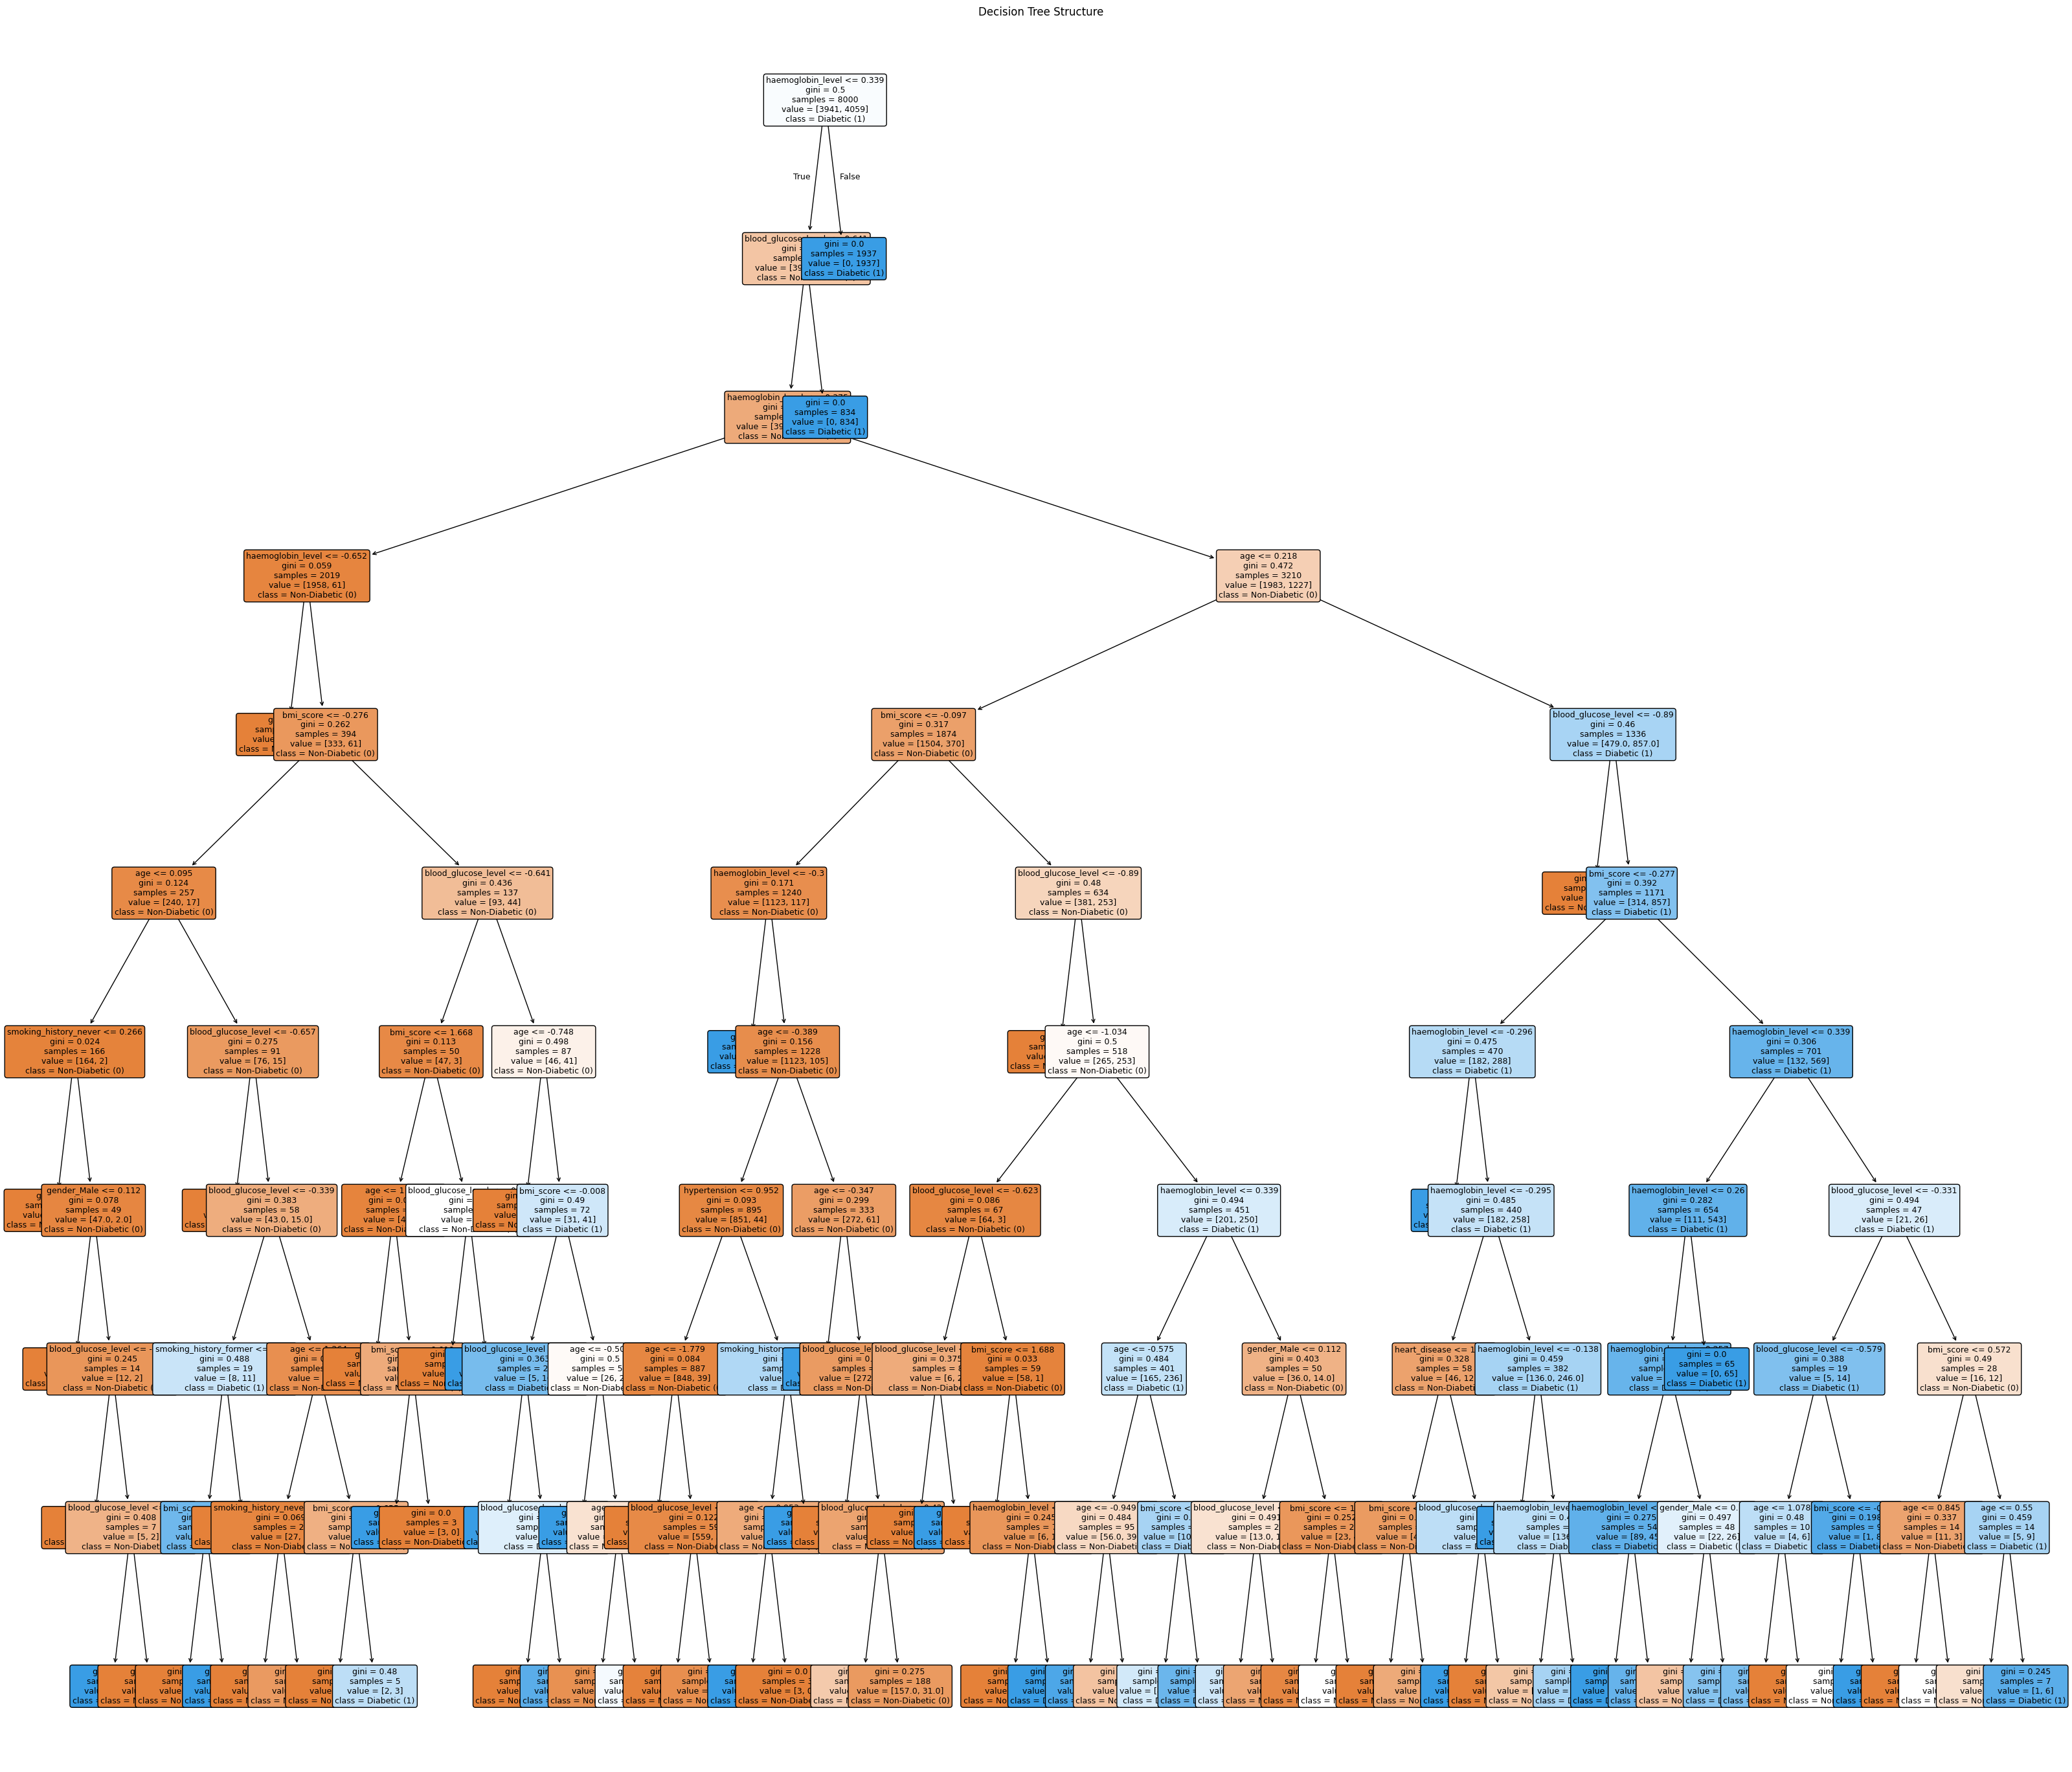

In [ ]:
#@title DECISION TREE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Decision Tree model with hyperparameters
dtree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion='gini',
)

# Store predictions for overall classification report
all_y_test = []
all_y_pred = []
train_acc = []
test_acc = []

print("=== Decision Tree Evaluation ===")
for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit the model
    dtree.fit(X_train, y_train)

    # Predict on train and test sets
    y_train_pred = dtree.predict(X_train)
    y_test_pred = dtree.predict(X_test)

    # Store true labels and predictions for overall classification report
    all_y_test.extend(y_test)
    all_y_pred.extend(y_test_pred)

    # Calculate accuracy scores
    train_acc.append(dtree.score(X_train, y_train))
    test_acc.append(dtree.score(X_test, y_test))

# === Overall Classification Report ===
print("\n=== Overall Classification Report (Across All Folds) ===")
print(classification_report(all_y_test, all_y_pred))

# Calculate Overall Accuracy (Training and Testing)
overall_train_acc = np.mean(train_acc)
overall_test_acc = np.mean(test_acc)

print(f"\nOverall Training Accuracy:  {overall_train_acc:.4f}")
print(f"Overall Testing Accuracy:   {overall_test_acc:.4f}")

# Confusion Matrix (Total)
plt.figure(figsize=(4.5, 4))
sns.heatmap(confusion_matrix(all_y_test, all_y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('Decision Tree Confusion Matrix (All Folds)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# === Plot Training and Testing Accuracy Per Fold ===
plt.figure(figsize=(8, 5))
fold_range = range(1, len(train_acc) + 1)
plt.plot(fold_range, train_acc, marker='o', label='Training Accuracy', color='blue')
plt.plot(fold_range, test_acc, marker='o', label='Testing Accuracy', color='green')
plt.axhline(y=overall_test_acc, color='red', linestyle='--', label=f'Overall Test Acc: {overall_test_acc:.4f}')
plt.title("Decision Tree Accuracy Per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(fold_range)
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Fold Accuracies Summary ===
print("\nFold Accuracies (Testing):", [f"{acc:.4f}" for acc in test_acc])
print(f"Mean Testing Accuracy: {overall_test_acc:.4f}")


# === Visualize the Decision Tree structure ===
plt.figure(figsize=(40, 35))  # Larger figure size
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=["Non-Diabetic (0)", "Diabetic (1)"],
          rounded=True, fontsize=9)  # Slightly larger font size for readability
plt.title("Decision Tree Structure")
plt.show()

The code implements a Support Vector Machine (SVM) model to classify diabetes status using a cleaned dataset. It performs 5-fold cross-validation, training and testing the model on different splits of the data to ensure robust performance evaluation. StandardScaler is applied to standardize the features, a critical step for SVM effectiveness. The model uses the RBF kernel with specified hyperparameters (C=1, gamma=0.1) to handle non-linear decision boundaries. For each fold, training and testing accuracy are recorded, and confusion matrices are aggregated. Visualizations include a cumulative confusion matrix and a fold-wise accuracy plot to assess performance consistency. Finally, Principal Component Analysis (PCA) reduces the data to two dimensions to visually plot the data points along with the model’s support vectors, offering insight into the classification margins and decision boundary.

=== SVM Evaluation ===

=== Overall Classification Report (Across All Folds) ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Overall Training Accuracy:  0.9028
Overall Testing Accuracy:   0.8972


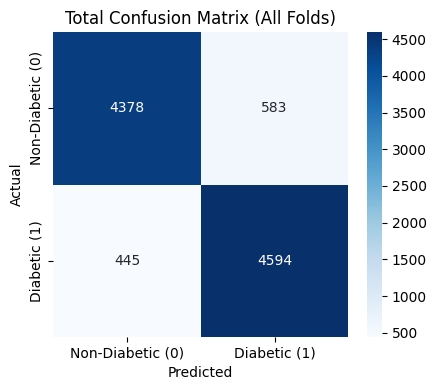

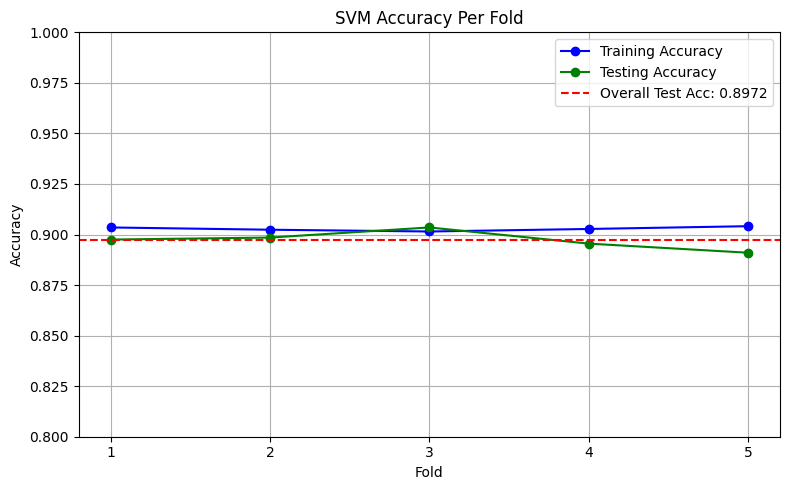


Fold Accuracies (Testing): ['0.8975', '0.8985', '0.9035', '0.8955', '0.8910']
Mean Testing Accuracy: 0.8972


<ipython-input-3-6b6b36f82f5c>:113: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(support_vectors[:, 0], support_vectors[:, 1], c='black', edgecolors='red', s=100, marker='x', label='Support Vectors')


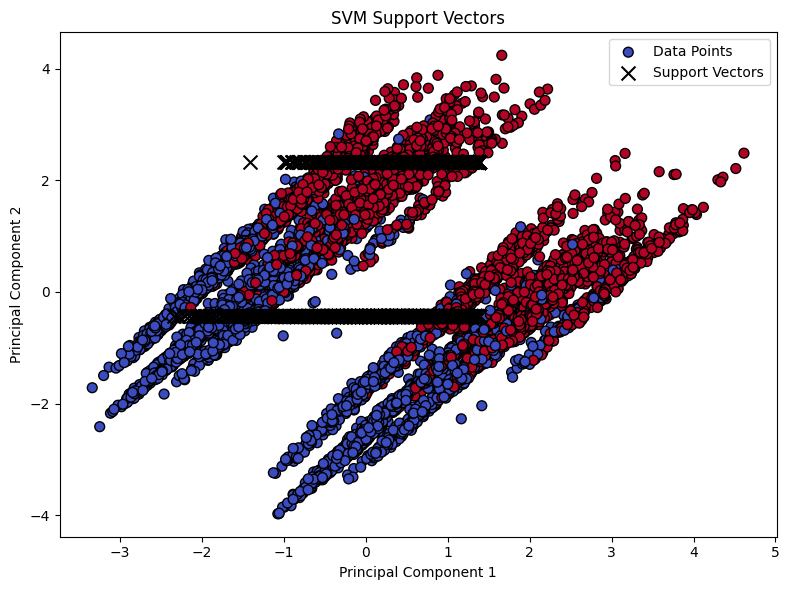

In [ ]:
  #@title SVM

  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.svm import SVC
  from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
  from sklearn.preprocessing import StandardScaler
  from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
  from sklearn.decomposition import PCA

  # Load data
  df = pd.read_csv('diabetes_clean.csv')
  X = df.drop(columns=['is_diabetic'])
  y = df['is_diabetic']

  # Standardize the features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  # SVM model
  model = SVC(C=1, kernel='rbf' , gamma= 0.1)

  # K-Fold setup
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  # Tracking metrics
  all_y_test = []
  all_y_pred = []
  train_acc = []
  test_acc = []
  conf_matrix_total = np.array([[0, 0], [0, 0]])  # Initialize confusion matrix

  print("=== SVM Evaluation ===")

  for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
      X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
      y_train, y_test = y[train_idx], y[test_idx]

      model.fit(X_train, y_train)

      y_train_pred = model.predict(X_train)
      y_test_pred = model.predict(X_test)

      # Store true labels and predictions for overall classification report
      all_y_test.extend(y_test)
      all_y_pred.extend(y_test_pred)

      # Accuracy for training and testing
      train_acc.append(accuracy_score(y_train, y_train_pred))
      test_acc.append(accuracy_score(y_test, y_test_pred))

      # Accumulate confusion matrix
      conf_matrix_total += confusion_matrix(y_test, y_test_pred)

  # === Overall Classification Report ===
  print("\n=== Overall Classification Report (Across All Folds) ===")
  print(classification_report(all_y_test, all_y_pred))

  # Calculate Overall Accuracy (Training and Testing)
  overall_train_acc = np.mean(train_acc)
  overall_test_acc = np.mean(test_acc)

  print(f"\nOverall Training Accuracy:  {overall_train_acc:.4f}")
  print(f"Overall Testing Accuracy:   {overall_test_acc:.4f}")

  # Confusion Matrix (Total)
  plt.figure(figsize=(4.5, 4))
  sns.heatmap(conf_matrix_total, annot=True, fmt='d', cmap='Blues',
              xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
              yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
  plt.title('Total Confusion Matrix (All Folds)')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.tight_layout()
  plt.show()

  # === Plot Training and Testing Accuracy Per Fold ===
  plt.figure(figsize=(8, 5))
  fold_range = range(1, len(train_acc) + 1)
  plt.plot(fold_range, train_acc, marker='o', label='Training Accuracy', color='blue')
  plt.plot(fold_range, test_acc, marker='o', label='Testing Accuracy', color='green')
  plt.axhline(y=overall_test_acc, color='red', linestyle='--', label=f'Overall Test Acc: {overall_test_acc:.4f}')
  plt.title("SVM Accuracy Per Fold")
  plt.xlabel("Fold")
  plt.ylabel("Accuracy")
  plt.xticks(fold_range)
  plt.ylim(0.8, 1.0)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  # === Fold Accuracies Summary ===
  print("\nFold Accuracies (Testing):", [f"{acc:.4f}" for acc in test_acc])
  print(f"Mean Testing Accuracy: {overall_test_acc:.4f}")


  # === PCA for 2D visualization of support vectors ===
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X_scaled)  # Reduce features to 2D for visualization

  # Fit SVM model on the scaled data
  model.fit(X_scaled, y)

  # Plotting SVM with support vectors
  plt.figure(figsize=(8, 6))
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', marker='o', s=50, label='Data Points')

  # Plot support vectors
  support_vectors = model.support_vectors_
  plt.scatter(support_vectors[:, 0], support_vectors[:, 1], c='black', edgecolors='red', s=100, marker='x', label='Support Vectors')

  plt.title('SVM Support Vectors')
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')
  plt.legend()
  plt.tight_layout()
  plt.show()



=== Logistic Regression Evaluation ===

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89      4961
           1       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Confusion Matrix:
 [[4405  556]
 [ 547 4492]]
Training Accuracy: 0.8914
Testing Accuracy:  0.8897


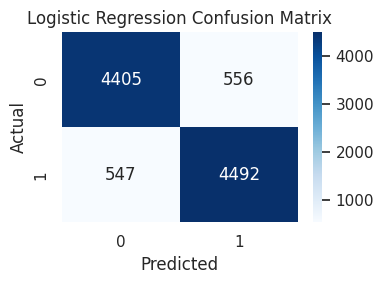


=== Decision Tree Evaluation ===

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.91      4961
           1       0.90      0.93      0.92      5039

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Confusion Matrix:
 [[4465  496]
 [ 350 4689]]
Training Accuracy: 0.9338
Testing Accuracy:  0.9158


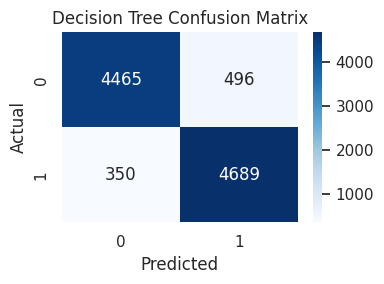


=== SVM Evaluation ===

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Confusion Matrix:
 [[4378  583]
 [ 445 4594]]
Training Accuracy: 0.9028
Testing Accuracy:  0.8972


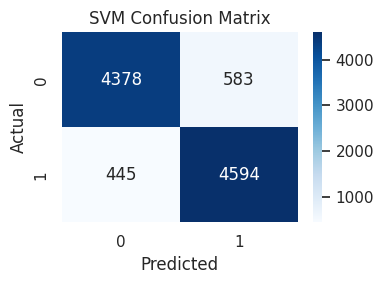

In [ ]:
#@title COMBO, 3 MODELS
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Data ===
df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

# === Standardize Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === K-Fold Setup ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# === Define Models and Parameters ===
models = {
    'Logistic Regression': LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, criterion='gini'),
    'SVM': SVC(C=1.0, kernel='rbf', gamma=0.1)
}

# === Run and Evaluate Each Model ===
for name, model in models.items():
    print(f"\n=== {name} Evaluation ===")

    # Cross-validated predictions
    y_pred = cross_val_predict(model, X_scaled, y, cv=kf)

    # Evaluation reports
    print("\nClassification Report:\n", classification_report(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

    # Accuracy Scores
    test_acc = cross_val_score(model, X_scaled, y, cv=kf)
    train_acc = []

    for train_idx, test_idx in kf.split(X_scaled):
        model.fit(X_scaled[train_idx], y[train_idx])
        train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))

    print(f"Training Accuracy: {np.mean(train_acc):.4f}")
    print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")

    # Confusion Matrix Plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


# BAGGING ENSEMBLE

## **BEST RANDOM FOREST (DT) MODEL**

This code uses a Random Forest model with Decision Trees as base learners in a bagging ensemble to predict whether a patient is diabetic. The dataset is first standardized using StandardScaler to make sure all input features are on the same scale. The model is built with the following hyperparameters: 90 trees (n_estimators=90), a maximum tree depth of 30 (max_depth=30), a minimum of 4 samples required to split a node (min_samples_split=4), and at least 1 sample per leaf (min_samples_leaf=1). The model is evaluated using 5-fold stratified cross-validation to ensure balanced representation of diabetic and non-diabetic classes in each fold.

To assess its performance, the model generates a classification report and confusion matrix, and it computes the average training accuracy, testing accuracy, F1 score, precision, and recall across all folds. The results show a very high training accuracy of 0.9986, indicating the model fits the training data extremely well, and a strong testing accuracy of 0.9342, showing it performs well on unseen data. The average F1 score of 0.9359 confirms the model’s strong balance between precision and recall. Visualizations such as a heatmap of the confusion matrix and a line chart of fold-wise accuracy further support the evaluation. Among all the bagging ensemble models tested, this Random Forest model delivered the best results, making it the most effective choice for this task.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(
    n_estimators=90,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=1
)

name = "Random Forest (DT)"

print(f"\n=== {name} Evaluation ===")
y_pred = cross_val_predict(model, X_scaled, y, cv=kf, n_jobs=-1)
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf, n_jobs=-1)
train_acc, f1_scores, precision_scores, recall_scores = [], [], [], []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))
    precision_scores.append(precision_score(y[test_idx], y_fold_pred))
    recall_scores.append(recall_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")
print(f"Avg Precision:     {np.mean(precision_scores):.4f}")
print(f"Avg Recall:        {np.mean(recall_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title(f'{name} Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")
for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="black")
plt.title(f"{name} Model Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()
print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")

## **BEST BAGGED LOGISTIC REGRESSION MODEL**

This code uses a Bagging ensemble approach with Logistic Regression as the base learner to classify whether a patient is diabetic. The dataset is first scaled using StandardScaler to standardize the features, improving the performance of logistic regression. The bagging model is built using BaggingClassifier with 10 logistic regression models (n_estimators=10), each configured with a regularization strength of C=0.1, the 'lbfgs' solver, and a maximum of 1000 iterations to ensure convergence. Bootstrap sampling (bootstrap=True) is enabled so that each base learner is trained on a randomly sampled subset of the data.

The model is evaluated using 5-fold stratified cross-validation to maintain a balanced class distribution in each fold. Metrics such as training accuracy, testing accuracy, F1 score, precision, and recall are computed to assess performance. Based on the evaluation results, the Bagged Logistic Regression model achieved a training accuracy of 0.9173, testing accuracy of 0.9102, and an average F1 score of 0.9110. These results indicate that the model provides consistent and reliable predictions across different data splits, with good balance between sensitivity and precision. Although it performs slightly lower than tree-based ensemble methods, it still offers solid performance and benefits from the interpretability of logistic regression. The confusion matrix and fold accuracy plots give further insight into prediction quality and consistency across folds.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = BaggingClassifier(
    estimator=LogisticRegression(
        C=0.1,
        solver='lbfgs',
        max_iter=1000
    ),
    n_estimators=10,
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)

name = "Bagged Logistic Regression"

print(f"\n=== {name} Evaluation ===")
y_pred = cross_val_predict(model, X_scaled, y, cv=kf, n_jobs=-1)
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf, n_jobs=-1)
train_acc, f1_scores, precision_scores, recall_scores = [], [], [], []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))
    precision_scores.append(precision_score(y[test_idx], y_fold_pred))
    recall_scores.append(recall_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")
print(f"Avg Precision:     {np.mean(precision_scores):.4f}")
print(f"Avg Recall:        {np.mean(recall_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title(f'{name} Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")
for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="black")
plt.title(f"{name} Model Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()
print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")

## **BEST BAGGED DECISION TREE MODEL**

This code implements a Bagging ensemble model using Decision Trees as the base learners to classify whether a patient is diabetic. The dataset is first preprocessed using StandardScaler to normalize the input features. The model is built using a BaggingClassifier with 50 decision trees (n_estimators=50), where each tree has a maximum depth of 10 (max_depth=10), uses the Gini impurity criterion (criterion='gini'), and allows a minimum of 2 samples to split (min_samples_split=2) and at least 1 sample per leaf (min_samples_leaf=1). Bagging is enabled (bootstrap=True) to train each tree on a random subset of the data, which helps reduce variance and improve generalization.

The model is evaluated using 5-fold stratified cross-validation to maintain the class distribution across folds. Key metrics such as training accuracy, testing accuracy, F1 score, precision, and recall are calculated to assess its overall performance. Based on the results, the model achieved a training accuracy of 0.9771, a testing accuracy of 0.9264, and an average F1 score of 0.9286. These scores indicate that the model performs well both on training and unseen data, with a strong balance between precision and recall. Additionally, a confusion matrix heatmap and a fold-wise accuracy line chart are generated to provide visual insight into its prediction capabilities. While it performs slightly lower than the Random Forest model, this Bagged Decision Tree setup still offers solid performance and good generalization.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion='gini'
    ),
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)

name = "Bagged Decision Tree"

print(f"\n=== {name} Evaluation ===")
y_pred = cross_val_predict(model, X_scaled, y, cv=kf, n_jobs=-1)
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf, n_jobs=-1)
train_acc, f1_scores, precision_scores, recall_scores = [], [], [], []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))
    precision_scores.append(precision_score(y[test_idx], y_fold_pred))
    recall_scores.append(recall_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")
print(f"Avg Precision:     {np.mean(precision_scores):.4f}")
print(f"Avg Recall:        {np.mean(recall_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title(f'{name} Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")
for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="black")
plt.title(f"{name} Model Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()
print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")

## **BEST BAGGED SVM MODEL**

This code uses Bagging with Support Vector Machines (SVM) as the base classifier to predict whether a patient is diabetic. The input features are standardized using StandardScaler, which is important for SVM performance. The model uses a radial basis function (RBF) kernel SVM with the following hyperparameters: C=1.0 (controls the trade-off between smooth decision boundary and classification accuracy), gamma=0.1 (defines how far the influence of a single training example reaches), and n_estimators=150, meaning 150 SVM models are trained using different bootstrap samples.

The evaluation is performed using 5-fold stratified cross-validation to ensure both diabetic and non-diabetic cases are proportionally represented in each fold. After training, performance is measured using training accuracy, testing accuracy, F1 score, precision, and recall. The Bagged SVM model achieved a training accuracy of 0.9713, testing accuracy of 0.9266, and an average F1 score of 0.9276. These results suggest the model generalizes well and is capable of making highly accurate predictions. The model also performs consistently across all folds, as shown by the fold-wise accuracy plot and confusion matrix, further reinforcing its reliability for classification tasks in this dataset.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = BaggingClassifier(
    estimator=SVC(
        C=1.0,
        kernel='rbf',
        gamma=0.1,
    ),
    n_estimators=150,
    random_state=24,
    n_jobs=-1,
    bootstrap=True
)

name = "Bagged SVM"

print(f"\n=== {name} Evaluation ===")
y_pred = cross_val_predict(model, X_scaled, y, cv=kf, n_jobs=-1)
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf, n_jobs=-1)
train_acc, f1_scores, precision_scores, recall_scores = [], [], [], []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))
    precision_scores.append(precision_score(y[test_idx], y_fold_pred))
    recall_scores.append(recall_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")
print(f"Avg Precision:     {np.mean(precision_scores):.4f}")
print(f"Avg Recall:        {np.mean(recall_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
            yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title(f'{name} Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")
for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="black")
plt.title(f"{name} Model Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()
print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")






#**BOOSTING ENSEMBLE**






## **BEST GRADIENTBOOSTING - DECISION TREES MODEL**

  The GradientBoostingClassifier is configured with 150 estimators, a learning rate of 0.2, maximum tree depth of 2, and a minimum samples split of 3. These parameters control how complex each tree is, how quickly the model learns, and how much each weak learner contributes to the overall prediction.

  To evaluate the model's performance, 5-fold stratified cross-validation is used. This ensures that both diabetic and non-diabetic cases are proportionally represented in each training and test split. After training on each fold, the model is assessed using classification metrics such as precision, recall, F1 score, training accuracy, and testing accuracy. The model achieved a training accuracy of 0.9715, testing accuracy of 0.9656, and an average F1 score of 0.9654, which shows strong predictive ability and generalization. The classification report shows precision and recall values of 0.97 for both classes, confirming balanced and consistent performance. The confusion matrix and fold accuracy plot further validate the model’s reliability across all folds, making it a high-performing choice for this classification task.


=== Gradient Boosting with Decision Tree Evaluation ===

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.95      0.98      0.97      4961
    Diabetic (1)       0.98      0.95      0.97      5039

        accuracy                           0.97     10000
       macro avg       0.97      0.97      0.97     10000
    weighted avg       0.97      0.97      0.97     10000

Confusion Matrix:
 [[4853  108]
 [ 236 4803]]
Training Accuracy: 0.9715
Testing Accuracy:  0.9656
Avg F1 Score:      0.9654


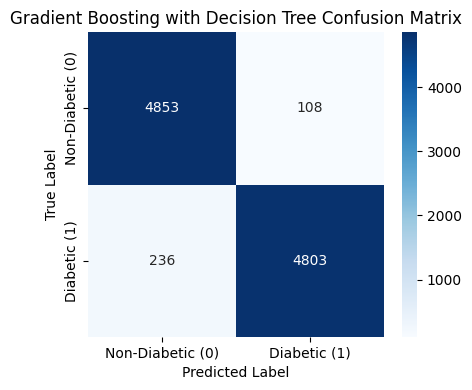

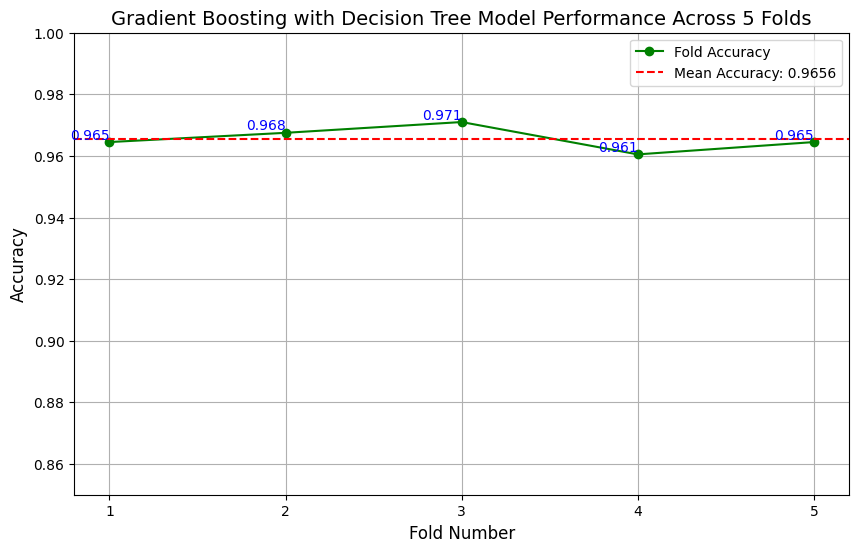

Fold Accuracies: [0.9645 0.9675 0.971  0.9605 0.9645]
Mean Accuracy: 0.9656


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_dt = DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, criterion='gini', random_state=42)

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.2,
    max_depth=2,
    min_samples_split=3,
    random_state=42,
)

print("\n=== Gradient Boosting with Decision Tree Evaluation ===")

y_pred = cross_val_predict(gb_model, X_scaled, y, cv=kf)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(gb_model, X_scaled, y, cv=kf)
train_acc = []
f1_scores = []

for train_idx, test_idx in kf.split(X_scaled, y):
    gb_model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = gb_model.predict(X_scaled[test_idx])

    train_acc.append(gb_model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('Gradient Boosting with Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="green", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")

for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("Gradient Boosting with Decision Tree Model Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()

print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")


## **BEST XGBOOST - DECISION TREES MODEL**

The XGBoostClassifier is configured with 500 estimators, a learning rate of 0.2, and a maximum tree depth of 3. It uses a subsample rate of 1, meaning the full dataset is used in each boosting round. The base learner is a Decision Tree with a maximum depth of 10, Gini impurity criterion, and minimal split settings, allowing for fine-grained splits within each boosting stage.

Evaluation is performed using 5-fold stratified cross-validation to ensure both diabetic and non-diabetic cases are evenly distributed in each fold. After training, the model is assessed using metrics such as training accuracy, testing accuracy, F1 score, precision, and recall. The model achieved a training accuracy of 0.9912, a testing accuracy of 0.9672, and an average F1 score of 0.9671. These results show that the model is highly accurate and generalizes well, with minimal overfitting. The classification report indicates that both classes were classified with high precision and recall, and the confusion matrix confirms consistent and reliable predictions. The fold-wise accuracy plot further demonstrates the stability of the model across all folds, reinforcing its strength for classification tasks on this dataset.


=== XGBoost with Decision Tree as Base Estimator Evaluation ===

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.96      0.98      0.97      4961
    Diabetic (1)       0.98      0.96      0.97      5039

        accuracy                           0.97     10000
       macro avg       0.97      0.97      0.97     10000
    weighted avg       0.97      0.97      0.97     10000

Confusion Matrix:
 [[4858  103]
 [ 225 4814]]
Training Accuracy: 0.9912
Testing Accuracy:  0.9672
Avg F1 Score:      0.9671


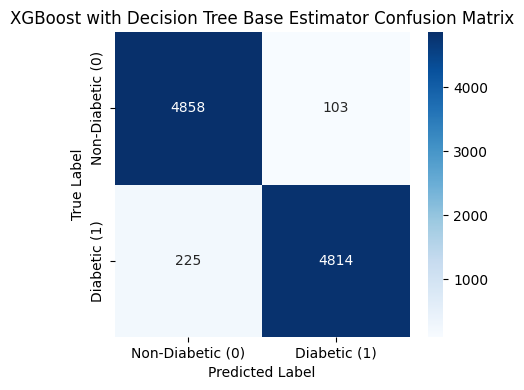

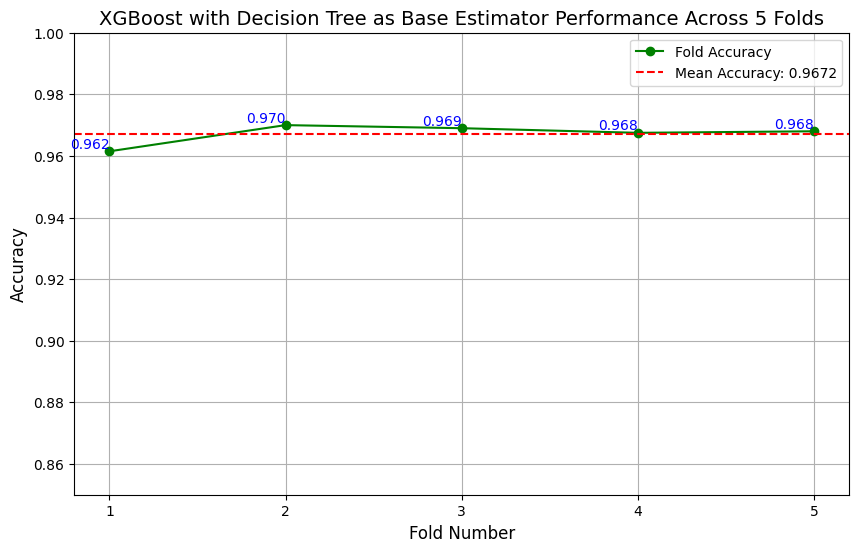

Fold Accuracies: [0.9615 0.97   0.969  0.9675 0.968 ]
Mean Accuracy: 0.9672


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_dt = DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1, criterion='gini')

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.2,
    max_depth=3,
    subsample=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    base_estimator=base_dt
)

print(f"\n=== XGBoost with Decision Tree as Base Estimator Evaluation ===")

y_pred = cross_val_predict(xgb_model, X_scaled, y, cv=kf)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(xgb_model, X_scaled, y, cv=kf)
train_acc = []
f1_scores = []

for train_idx, test_idx in kf.split(X_scaled, y):
    xgb_model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = xgb_model.predict(X_scaled[test_idx])

    train_acc.append(xgb_model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('XGBoost with Decision Tree Base Estimator Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="green", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")

for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("XGBoost with Decision Tree as Base Estimator Performance Across 5 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()

print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")


## **BEST ADABOOST - DECISION TREES MODEL**

The base model is a Decision Tree configured with a maximum depth of 10 and Gini impurity for splitting. AdaBoost is configured with 200 estimators, a learning rate of 0.1, and uses the SAMME boosting algorithm to sequentially improve performance by focusing on misclassified instances in each iteration.

The evaluation is performed using 5-fold stratified cross-validation to ensure balanced class representation across all folds. After training, model performance is evaluated using training accuracy, testing accuracy, precision, recall, and F1 score. The model achieved a training accuracy of 0.9857, a testing accuracy of 0.9627, and an average F1 score of 0.9626. The classification report shows high precision and recall for both diabetic and non-diabetic classes, while the confusion matrix confirms accurate classification with relatively low false positives and false negatives. The fold-wise accuracy plot shows consistent results across all splits, indicating strong generalization and reliability of the AdaBoost model on this dataset.


=== AdaBoost with Decision Tree Evaluation ===

Classification Report:
                precision    recall  f1-score   support

Non-Diabetic 0       0.95      0.97      0.96      4961
    Diabetic 1       0.97      0.95      0.96      5039

      accuracy                           0.96     10000
     macro avg       0.96      0.96      0.96     10000
  weighted avg       0.96      0.96      0.96     10000

Confusion Matrix:
 [[4824  137]
 [ 236 4803]]
Training Accuracy: 0.9857
Testing Accuracy:  0.9627
Avg F1 Score:      0.9626


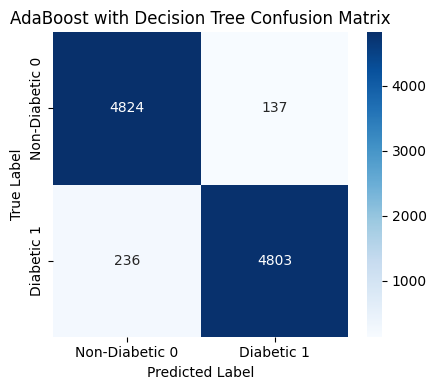

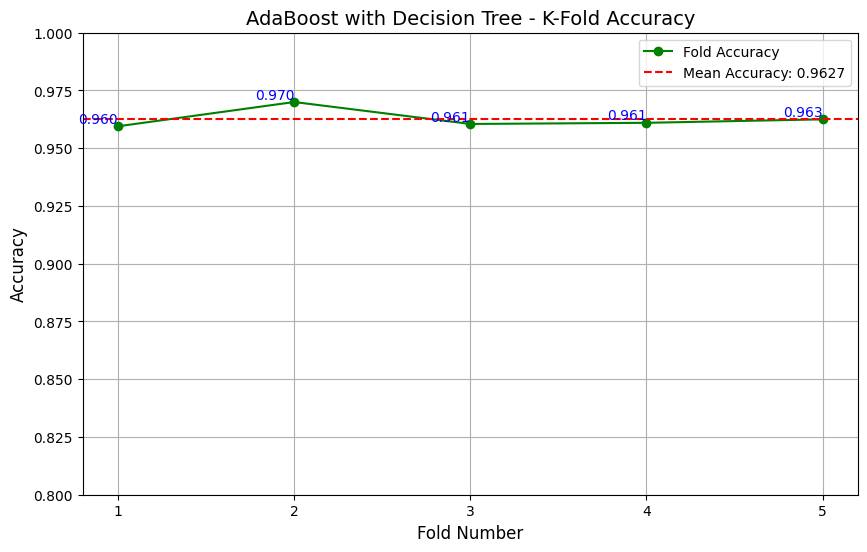

Fold Accuracies: [0.9595 0.97   0.9605 0.961  0.9625]
Mean Accuracy: 0.9627


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion='gini',
    random_state=42
)

model = AdaBoostClassifier(
    estimator=base_dt,
    n_estimators=200,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)

print("\n=== AdaBoost with Decision Tree Evaluation ===")

y_pred = cross_val_predict(model, X_scaled, y, cv=kf)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic 0", "Diabetic 1"]))

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf)
train_acc = []
f1_scores = []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Diabetic 0", "Diabetic 1"],
            yticklabels=["Non-Diabetic 0", "Diabetic 1"])
plt.title('AdaBoost with Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="green", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")

for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("AdaBoost with Decision Tree - K-Fold Accuracy", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.80, 1.0)
plt.legend()
plt.grid(True)
plt.show()

print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")


## **BEST ADABOOST - LOGISTIC REGRESSION MODEL**

The base learner is configured with a regularization strength of 0.1, the ‘lbfgs’ solver, and a maximum of 1000 iterations. AdaBoost is set to use 250 estimators, a learning rate of 0.6, and the SAMME boosting algorithm, which works well with classifiers that support discrete outputs.

The model is evaluated using 5-fold stratified cross-validation to maintain proportional class distribution across each fold. After training, its performance is assessed using training accuracy, testing accuracy, precision, recall, and F1 score. The model achieved a training accuracy of 0.8875, testing accuracy of 0.8890, and an average F1 score of 0.8946. The classification report shows that the model performs slightly better at identifying diabetic cases than non-diabetic ones, with higher recall for the diabetic class. The confusion matrix reveals that while predictions are fairly balanced, there is a notable number of false negatives in the non-diabetic class. The fold-wise accuracy plot shows consistent results across all folds, suggesting moderate generalization. Overall, the model performs reliably, though less strongly than tree-based boosting approaches, making it suitable for simpler scenarios where interpretability and speed are prioritized.


=== AdaBoost with Logistic Regression Evaluation ===

Classification Report:
                precision    recall  f1-score   support

Non-Diabetic 0       0.93      0.84      0.88      4961
    Diabetic 1       0.86      0.93      0.89      5039

      accuracy                           0.89     10000
     macro avg       0.89      0.89      0.89     10000
  weighted avg       0.89      0.89      0.89     10000

Confusion Matrix:
 [[4181  780]
 [ 330 4709]]
Training Accuracy: 0.8875
Testing Accuracy:  0.8890
Avg F1 Score:      0.8946


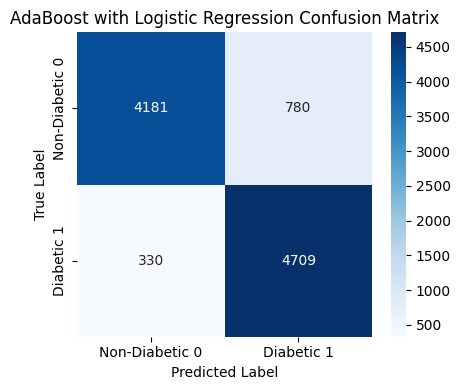

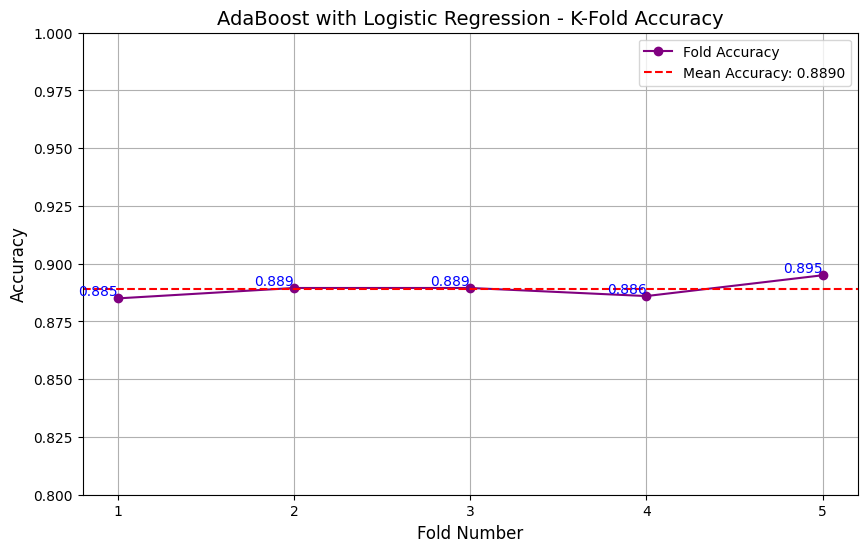

Fold Accuracies: [0.885  0.8895 0.8895 0.886  0.895 ]
Mean Accuracy: 0.8890


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes_clean.csv')
X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_lr = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)

model = AdaBoostClassifier(estimator=base_lr, n_estimators=250, learning_rate=0.6, algorithm='SAMME', random_state=42)

print("\n=== AdaBoost with Logistic Regression Evaluation ===")

y_pred = cross_val_predict(model, X_scaled, y, cv=kf)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Non-Diabetic 0", "Diabetic 1"]))

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

test_acc = cross_val_score(model, X_scaled, y, cv=kf)
train_acc = []
f1_scores = []

for train_idx, test_idx in kf.split(X_scaled, y):
    model.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = model.predict(X_scaled[test_idx])
    train_acc.append(model.score(X_scaled[train_idx], y[train_idx]))
    f1_scores.append(f1_score(y[test_idx], y_fold_pred))

print(f"Training Accuracy: {np.mean(train_acc):.4f}")
print(f"Testing Accuracy:  {np.mean(test_acc):.4f}")
print(f"Avg F1 Score:      {np.mean(f1_scores):.4f}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Diabetic 0", "Diabetic 1"],
            yticklabels=["Non-Diabetic 0", "Diabetic 1"])
plt.title('AdaBoost with Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", linestyle="-", color="purple", label="Fold Accuracy")
plt.axhline(y=np.mean(test_acc), color="red", linestyle="--", label=f"Mean Accuracy: {np.mean(test_acc):.4f}")

for i, score in enumerate(test_acc):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("AdaBoost with Logistic Regression - K-Fold Accuracy", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(test_acc) + 1))
plt.ylim(0.80, 1.0)
plt.legend()
plt.grid(True)
plt.show()

print(f"Fold Accuracies: {test_acc}")
print(f"Mean Accuracy: {np.mean(test_acc):.4f}")







#**MULTILAYER PERCEPTRON (MLP) ALGORITHM**






## **BEST MLP MODEL - Experiment 57**

The MLP model is configured with one hidden layer containing 100 neurons, the ReLU activation function, the Adam optimizer, a learning rate of 0.01, and a maximum of 1000 iterations for convergence.

After training the model, predictions are made and evaluated using accuracy, precision, recall, and F1 score. The model achieved a training accuracy of 0.9345, a testing accuracy of 0.9124, and an average F1 score of 0.9103. The classification report indicates balanced precision and recall for both diabetic and non-diabetic classes, showing the model’s ability to generalize well to new data. The confusion matrix shows relatively low false positives and false negatives, confirming the model's solid predictive reliability. The matrix of predictions and reported class probabilities further demonstrate the MLP's ability to assign high confidence to its predictions. This result indicates that the MLP model is a strong candidate for classification tasks involving non-linear patterns and high-dimensional feature spaces.

Probability Results:  [[0.02627193 0.97372807]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9124

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.93      0.91      1264
    Diabetic (1)       0.92      0.90      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9345
Testing Accuracy:  0.9124
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1170   94]
 [ 125 1111]]


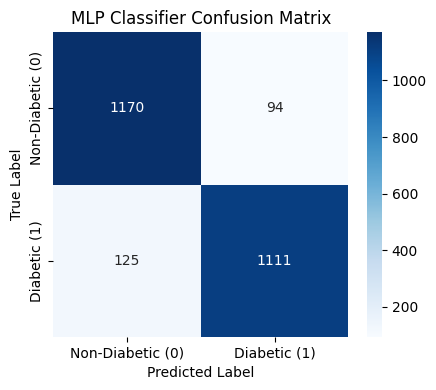

In [ ]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()